<a href="https://colab.research.google.com/github/recommended131225435/vit-registers-reproduction/blob/main/notebooks/full_training_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full training runs: our ViT, 0 vs 4 registers (Google Colab)

Trains ViT-Tiny on **all 100,000 Tiny-ImageNet images for 50 epochs**, twice:

| Run | Registers | Augmentation | Training images |
|---|---|---|---|
| `tiny_reg0` | 0 | basic (random crop + flip) | 100,000 |
| `tiny_reg4` | 4 | basic (random crop + flip) | 100,000 |

Then it makes a results table and graph.

**Time:** about 75 minutes per run, so roughly 2.5 hours in total.

**Before running:** `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all`.
Keep this tab open and your laptop awake while it runs.

**Already finished runs** print `Resuming from epoch 50` and are not trained again; their full epoch-by-epoch history is printed in step 5 from the saved logs.

**If Colab disconnects:** just do `Runtime → Run all` again. Progress is saved to your
Google Drive after every epoch, so training continues from where it stopped.

## 0. Setup: get the code

In [1]:
import os

REPO_URL = "https://github.com/recommended131225435/vit-registers-reproduction.git"

if os.path.exists("../src") and not os.path.exists("src"):  # opened from inside notebooks/
    %cd ..
if not os.path.exists("src"):                                  # fresh Colab session
    !git clone -q {REPO_URL} repo
    %cd repo
else:
    !git pull -q                                               # make sure the code is up to date
!pip install -q -r requirements.txt

import torch
from IPython.display import Image, Markdown, display
print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE (switch runtime to T4!)")

/content/repo
torch 2.11.0+cpu | GPU: NONE (switch runtime to T4!)


## 1. Connect Google Drive
The trained models and logs are saved here, so nothing is lost if Colab disconnects. Click **Allow** when asked.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

RUN_DIR = "/content/drive/MyDrive/vit-registers-runs"
os.makedirs(RUN_DIR, exist_ok=True)
print("Runs will be saved in", RUN_DIR)

Mounted at /content/drive
Runs will be saved in /content/drive/MyDrive/vit-registers-runs


## 2. Train without registers (about 75 min)

In [3]:
!python -m src.train --size tiny --registers 0 --epochs 50 --resume --out {RUN_DIR}/tiny_reg0

100% 248M/248M [01:18<00:00, 3.15MB/s]
Resuming from epoch 50 (step 19500)
tiny ViT | 0 registers | basic augmentation | 5,427,080 params | device cpu
final: {'val_acc': 0.3899, 'val_loss': 3.537073891067505, 'epochs_run': 50, 'steps': 19500}


## 3. Train with 4 registers (about 75 min)

In [4]:
!python -m src.train --size tiny --registers 4 --epochs 50 --resume --out {RUN_DIR}/tiny_reg4

Tiny-ImageNet already present at data/tiny-imagenet-200
Resuming from epoch 50 (step 19500)
tiny ViT | 4 registers | basic augmentation | 5,427,848 params | device cpu
final: {'val_acc': 0.3786, 'val_loss': 3.591741558074951, 'epochs_run': 50, 'steps': 19500}


## 4. Results table and graph

[report] README section FULL_TRAINING updated
Validation accuracy after the last epoch (we do not pick the best epoch, because the validation set is also our test set).

| Model | Augmentation | Registers | Train images | Epochs | Val accuracy | Train accuracy | Val loss (final / lowest) | Time (min) |
|---|---|---|---|---|---|---|---|---|
| ViT-Tiny | basic | 0 | 100,000 | 50 | **38.99%** | 91.6% | 3.537 / 3.225 | 75 |
| ViT-Tiny | basic | 4 | 100,000 | 50 | **37.86%** | 91.5% | 3.592 / 3.246 | 75 |

- Effect of adding registers (basic augmentation): **-1.13 points**.
- Paper (Table 2a, ImageNet top-1): DeiT-III 84.7 → 84.7, OpenCLIP 78.2 → 78.1, DINOv2 84.3 → 84.8, i.e. registers do not hurt accuracy. Our absolute accuracies are not comparable with the paper's (different dataset, much smaller model, shorter training); only the with/without-registers differences are. Each setting was trained once (seed 0), so differences of a few tenths of a point may be random variation.
- How to rea

Validation accuracy after the last epoch (we do not pick the best epoch, because the validation set is also our test set).

| Model | Augmentation | Registers | Train images | Epochs | Val accuracy | Train accuracy | Val loss (final / lowest) | Time (min) |
|---|---|---|---|---|---|---|---|---|
| ViT-Tiny | basic | 0 | 100,000 | 50 | **38.99%** | 91.6% | 3.537 / 3.225 | 75 |
| ViT-Tiny | basic | 4 | 100,000 | 50 | **37.86%** | 91.5% | 3.592 / 3.246 | 75 |

- Effect of adding registers (basic augmentation): **-1.13 points**.
- Paper (Table 2a, ImageNet top-1): DeiT-III 84.7 → 84.7, OpenCLIP 78.2 → 78.1, DINOv2 84.3 → 84.8, i.e. registers do not hurt accuracy. Our absolute accuracies are not comparable with the paper's (different dataset, much smaller model, shorter training); only the with/without-registers differences are. Each setting was trained once (seed 0), so differences of a few tenths of a point may be random variation.
- How to read the overfitting columns: a large gap between train and validation accuracy, and a final validation loss well above its lowest value, both mean the model is memorising the training images.



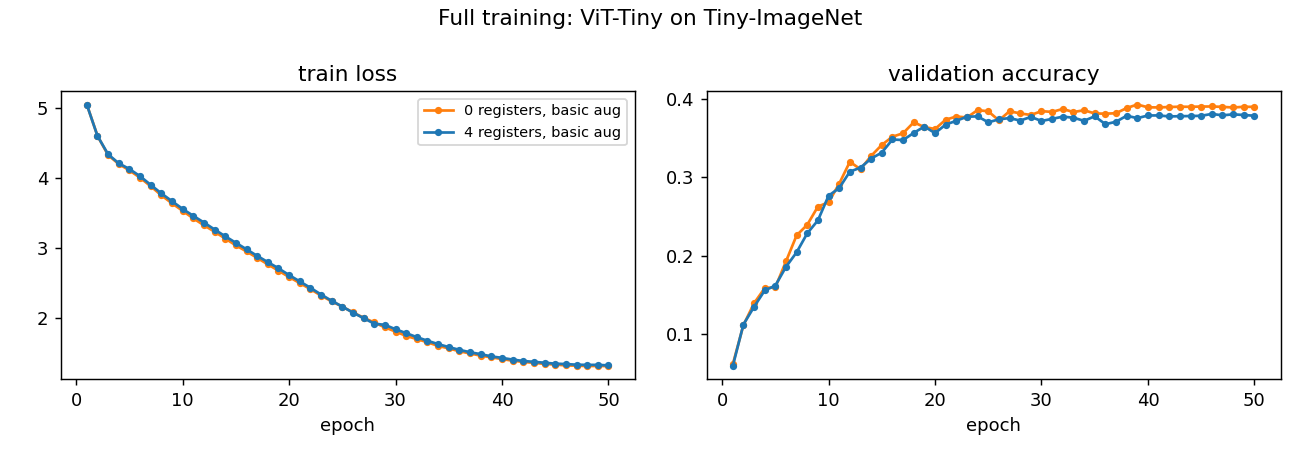

In [5]:
!python -m scripts.summarise_training --runs {RUN_DIR}/tiny_reg0 {RUN_DIR}/tiny_reg4

display(Markdown(open("results/runs/full_training_summary.md").read().split("![")[0]))
display(Image("results/figures/full_training_runs.png"))

## 5. Full training logs (every epoch)
Printed from the log files saved on Google Drive during training, so the complete history is shown even when the runs finished in an earlier session.

In [6]:
import csv

for name in ["tiny_reg0", "tiny_reg4"]:
    print(f"===== {name} =====")
    with open(f"{RUN_DIR}/{name}/log.csv") as f:
        for r in csv.DictReader(f):
            print(f"epoch {int(r['epoch']):3d} | train loss {float(r['train_loss']):.3f} acc {float(r['train_acc']):.3f} | "
                  f"val loss {float(r['val_loss']):.3f} acc {float(r['val_acc']):.3f} | {float(r['epoch_time_s']):.0f}s")
    print()

===== tiny_reg0 =====
epoch   1 | train loss 5.048 acc 0.036 | val loss 4.802 acc 0.061 | 91s
epoch   2 | train loss 4.600 acc 0.089 | val loss 4.410 acc 0.112 | 86s
epoch   3 | train loss 4.324 acc 0.129 | val loss 4.255 acc 0.140 | 86s
epoch   4 | train loss 4.197 acc 0.152 | val loss 4.116 acc 0.159 | 90s
epoch   5 | train loss 4.105 acc 0.168 | val loss 4.115 acc 0.160 | 88s
epoch   6 | train loss 4.001 acc 0.186 | val loss 3.967 acc 0.193 | 89s
epoch   7 | train loss 3.879 acc 0.213 | val loss 3.825 acc 0.226 | 88s
epoch   8 | train loss 3.750 acc 0.236 | val loss 3.733 acc 0.240 | 87s
epoch   9 | train loss 3.635 acc 0.262 | val loss 3.618 acc 0.263 | 89s
epoch  10 | train loss 3.527 acc 0.282 | val loss 3.637 acc 0.268 | 90s
epoch  11 | train loss 3.419 acc 0.308 | val loss 3.508 acc 0.292 | 91s
epoch  12 | train loss 3.321 acc 0.329 | val loss 3.386 acc 0.320 | 91s
epoch  13 | train loss 3.228 acc 0.350 | val loss 3.425 acc 0.310 | 92s
epoch  14 | train loss 3.131 acc 0.372 | v

## 6. Download the results
The zip holds the logs, the graph and the updated README (not the model weights; those stay on your Google Drive).

In [7]:
!zip -qr full_training_results.zip results/runs results/figures/full_training_runs.png README.md

from google.colab import files
files.download("full_training_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>